---
numbering: false
---


# 10.2. Low-Rank Approximation

In [Chapter 10.1](./01-computing-svd.ipynb), we learned how to find the singular value decomposition of a matrix $X$, by using the eigenvalues and eigenvectors of $X^T X$ and $XX^T$.

$$X = U \Sigma V^T$$

Here, we'll apply our understanding to a useful practical application: **low-rank approximation**.

---

## Full and Compact SVD

But first, let's try and better understand _how_ the SVD decomposes a matrix.

### Full SVD

The version of the SVD we've constructed together is called the **full SVD**.

:::{figure} imgs/full-svd.png
:width: 1000px
:align: center
:caption: The singular value decomposition of $X$ is $X = U \Sigma V^T$, where the columns of $U$ are eigenvectors of $XX^T$, the columns of $V$ (rows of $V^T$) are eigenvectors of $X^TX$, and $\Sigma$ is a diagonal $n \times d$ matrix with the singular values of $X$ (square roots of the eigenvalues of $X^TX$) on the diagonal. The number of non-zero singular values is equal to $\text{rank}(X)$.
:::

In the full SVD, $U$ is $n \times n$, $\mathcal{\Sigma}$ is $n \times d$, and $V^T$ is $d \times d$. If $\text{rank}(X) = r$, then

- The first $r$ columns of $U$ are the left singular vectors of $X$ and are a basis for $\text{colsp}(X)$; the last $n - r$ columns of $U$ are a basis for $\text{nullsp}(X^T)$. Together, the columns of $U$ span $\mathbb{R}^n$.
- The first $r$ columns of $V$ are the right singular vectors of $X$ and are a basis for $\text{colsp}(X^T)$; the last $d - r$ columns of $V$ are a basis for $\text{nullsp}(X)$. Together, the columns of $V$ span $\mathbb{R}^d$.

The full SVD is nice for proofs, but is a little... annoying to use in real applications, because it contains a lot of 0's. The additional $n - r$ columns of $U$ and $d - r$ columns of $V$ are included to make $U$ and $V$ orthogonal matrices, but end up getting 0'd out when multiplied by the corresponding 0's in $\mathcal{\Sigma}$.

Remember that $X = U \Sigma V^T$ is equivalent to $XV = U \Sigma$, which says that, for $i = 1, 2, ..., d$,

$$X \vec v_i = \sigma_i \vec u_i$$

but when $i > r$, all this says is $\vec 0 = \vec 0$:

- $X \vec v_i = \vec 0$, since $\vec v_r$, $\vec v_{r+1}$, ..., $\vec v_d$ are all in $\text{nullsp}(X)$, and
- $\sigma_i = 0$, so $\sigma_i \vec u_i = 0 \vec u_i = \vec 0$.

### Compact SVD

The **compact SVD** throws away the 0's in $\mathcal{\Sigma}$ and the corresponding columns in $U$ and $V$. In the annotated figure above, it keeps only the <span style="color:#3d81f6; font-weight: bold">first $r$ columns in </span> $\color{#3d81f6} U$, <span style="color:orange; font-weight: bold">first r values in </span> $\color{orange} \Sigma$, and <span style="color:#d81a60; font-weight: bold">first r rows in </span> $\color{d81a60} V^T$.

That is, the compact SVD says $X = U_r \Sigma_r V_r^T$, where $U_r$ is $n \times r$, $\Sigma_r$ is $r \times r$, and $V_r^T$ is $r \times d$.

$$X =
\underbrace{
\begin{bmatrix}
{\color{#3d81f6} |} & {\color{#3d81f6} \cdots} & {\color{#3d81f6} |} \\
{\color{#3d81f6} \vec u_1} & {\color{#3d81f6} \cdots} & {\color{#3d81f6} \vec u_r} \\
{\color{#3d81f6} |} & {\color{#3d81f6} \cdots} & {\color{#3d81f6} |}
\end{bmatrix}
}_{U_r}
\underbrace{
\begin{bmatrix}
{\color{orange} \sigma_1} &        &    \\
       & {\color{orange} \ddots} &  \\
       &        & {\color{orange} \sigma_r}
\end{bmatrix}
}_{\Sigma_r}
\underbrace{
\begin{bmatrix}
{\color{#d81a60}\text{---} \:\: \vec v_1^T \:\: \text{---}} \\
{\color{#d81a60} \vdots} \\
{\color{#d81a60}\text{---} \:\: \vec v_r^T \:\: \text{---}}
\end{bmatrix}
}_{V_r^T}
$$

The full and compact SVDs are equivalent, in that $X = U \Sigma V^T = U_r \Sigma_r V_r^T$. But the individual components are of different sizes: 

| | Full SVD | Compact SVD | |
| --- | --- | --- | --- |
| $U$ | $n \times n$ | $n \times r$ | First $r$ columns of $U$ are basis for $\text{colsp}(X)$ |
| $\mathcal{\Sigma}$ | $n \times d$ | $r \times r$ | Number of non-zero $\sigma_i$'s is $r = \text{rank}(X)$ |
| $V^T$ | $d \times d$ | $r \times d$ | First $r$ rows of $V^T$ are basis for $\text{colsp}(X^T)$ |

$U_r$ and $V_r$ are no longer orthogonal matrices, since only square matrices can be orthogonal. However, their columns are still orthonormal, meaning $U_r^T U_r = I_{r \times r}$ and $V_r^T V_r = I_{r \times r}$.

---

## SVD as a Sum

The compact SVD hints at another way to think about $X$.

$$
\begin{align*}
X &=
\underbrace{
\begin{bmatrix}
{\color{#3d81f6} |} & {\color{#3d81f6} \cdots} & {\color{#3d81f6} |} \\
{\color{#3d81f6} \vec u_1} & {\color{#3d81f6} \cdots} & {\color{#3d81f6} \vec u_r} \\
{\color{#3d81f6} |} & {\color{#3d81f6} \cdots} & {\color{#3d81f6} |}
\end{bmatrix}
}_{U_r}
\underbrace{
\begin{bmatrix}
{\color{orange} \sigma_1} &        &    \\
       & {\color{orange} \ddots} &  \\
       &        & {\color{orange} \sigma_r}
\end{bmatrix}
}_{\Sigma_r}
\underbrace{
\begin{bmatrix}
{\color{#d81a60}\text{---} \:\: \vec v_1^T \:\: \text{---}} \\
{\color{#d81a60} \vdots} \\
{\color{#d81a60}\text{---} \:\: \vec v_r^T \:\: \text{---}}
\end{bmatrix}
}_{V_r^T} \\
&= \begin{bmatrix}
| & \cdots & | \\
{\color{orange} \sigma_1} {\color{#3d81f6} \vec u_1} & \cdots & {\color{orange} \sigma_r} {\color{#3d81f6} \vec u_r} \\
| & \cdots & |
\end{bmatrix}
\begin{bmatrix}
{\color{#d81a60}\text{---} \:\: \vec v_1^T \:\: \text{---}} \\
{\color{#d81a60} \vdots} \\
{\color{#d81a60}\text{---} \:\: \vec v_r^T \:\: \text{---}}
\end{bmatrix} \\
&= {\color{orange} \sigma_1} {\color{#3d81f6} \vec u_1} {\color{#d81a60}\vec v_1^T} + {\color{orange} \sigma_2} {\color{#3d81f6} \vec u_2} {\color{#d81a60}\vec v_2^T} + \cdots + {\color{orange} \sigma_r} {\color{#3d81f6} \vec u_r} {\color{#d81a60}\vec v_r^T}
\end{align*}
$$

Each term ${\color{orange} \sigma_i} {\color{#3d81f6} \vec u_i} {\color{#d81a60}\vec v_i^T}$ is an **outer product** of ${\color{#3d81f6} \vec u_i}$ and ${\color{#d81a60}\vec v_i}$, scaled by ${\color{orange} \sigma_i}$. Outer products are rank-one matrices: each column of ${\color{orange} \sigma_i} {\color{#3d81f6} \vec u_i} {\color{#d81a60}\vec v_i^T}$ is a multiple of ${\color{#3d81f6} \vec u_i}$, and each row of it is a multiple of ${\color{#d81a60}\vec v_i^T}$.

This outer product view of matrix multiplication is not one that we've emphasized a ton in this course, but it can be useful in certain contexts, as we're about to see. To see how it works, let's revisit our first example.

$$\underbrace{\begin{bmatrix}
3 & 2 & 5 \\
2 & 3 & 5 \\
2 & -2 & 0 \\
5 & 5 & 10
\end{bmatrix}}_X = \underbrace{\begin{bmatrix} {\color{#3d81f6} \frac{1}{\sqrt{6}}} & {\color{#ff8c00} \frac{1}{3\sqrt{2}}} & {\color{#aaa} -\frac{1}{\sqrt{3}}} & {\color{#aaa} -\frac{2}{3}}  \\ {\color{#3d81f6} \frac{1}{\sqrt{6}}} & {\color{#ff8c00} -\frac{1}{3\sqrt{2}}} & {\color{#aaa} -\frac{1}{\sqrt{3}}} & {\color{#aaa} \frac{2}{3}}  \\ {\color{#3d81f6} 0} & {\color{#ff8c00} \frac{2\sqrt{2}}{3}} & {\color{#aaa} 0} & {\color{#aaa} \frac{1}{3}}  \\ {\color{#3d81f6} \frac{2}{\sqrt{6}}} & {\color{#ff8c00} 0} & {\color{#aaa} \frac{1}{\sqrt{3}}} & {\color{#aaa} 0} \end{bmatrix}}_{U} \underbrace{\begin{bmatrix} {\color{#3d81f6} 15} & {\color{#aaa} 0} & {\color{#aaa} 0}  \\ {\color{#aaa} 0} & {\color{#ff8c00} 3} & {\color{#aaa} 0}  \\ {\color{#aaa} 0} & {\color{#aaa} 0} & {\color{#aaa} 0}  \\ {\color{#aaa} 0} & {\color{#aaa} 0} & {\color{#aaa} 0} \end{bmatrix}}_{\Sigma} \underbrace{\begin{bmatrix} {\color{#3d81f6} \frac{1}{\sqrt{6}}} & {\color{#3d81f6} \frac{1}{\sqrt{6}}} & {\color{#3d81f6} \frac{2}{\sqrt{6}}}  \\ {\color{#ff8c00} \frac{1}{\sqrt{2}}} & {\color{#ff8c00} -\frac{1}{\sqrt{2}}} & {\color{#ff8c00} 0}  \\ {\color{#aaa} \frac{1}{\sqrt{3}}} & {\color{#aaa} \frac{1}{\sqrt{3}}} & {\color{#aaa} -\frac{1}{\sqrt{3}}} \end{bmatrix}}_{V^T}$$

The summation view of the SVD says that:

\begin{align*}
X =\;& {\color{#3d81f6} 15}
\begin{bmatrix}
{\color{#3d81f6} \frac{1}{\sqrt{6}}} \\
{\color{#3d81f6} \frac{1}{\sqrt{6}}} \\
{\color{#3d81f6} 0} \\
{\color{#3d81f6} \frac{2}{\sqrt{6}}}
\end{bmatrix}
\begin{bmatrix}
{\color{#3d81f6} \frac{1}{\sqrt{6}}} & {\color{#3d81f6} \frac{1}{\sqrt{6}}} & {\color{#3d81f6} \frac{2}{\sqrt{6}}}
\end{bmatrix} + {\color{#ff8c00} 3}
\begin{bmatrix}
{\color{#ff8c00} \frac{1}{3\sqrt{2}}} \\
{\color{#ff8c00} -\frac{1}{3\sqrt{2}}} \\
{\color{#ff8c00} \frac{2\sqrt{2}}{3}} \\
{\color{#ff8c00} 0}
\end{bmatrix}
\begin{bmatrix}
{\color{#ff8c00} \frac{1}{\sqrt{2}}} & {\color{#ff8c00} -\frac{1}{\sqrt{2}}} & {\color{#ff8c00} 0}
\end{bmatrix} \\
&= \underbrace{{\color{#3d81f6} \begin{bmatrix} \frac{5}{2} & \frac{5}{2} & 5 \\ \frac{5}{2} & \frac{5}{2} & 5 \\ 0 & 0 & 0 \\ 5 & 5 & 10 \end{bmatrix}}}_{\text{rank-one matrix}} + \underbrace{{\color{orange} \begin{bmatrix} \frac{1}{2} & -\frac{1}{2} & 0 \\ -\frac{1}{2} & \frac{1}{2} & 0 \\ 2 & -2 & 0 \\ 0 & 0 & 0 \end{bmatrix}}}_{\text{rank-one matrix}}
\end{align*}

Since ${\color{#3d81f6} 15} > {\color{orange} 3}$, the first outer product contributes more to $X$ than the second one does. 

We can think of the singular values as representing the importance of the corresponding singular vectors in representing $X$. Since we sort singular values in decreasing order, $\sigma_1 \geq \sigma_2 \geq ... \geq \sigma_r > 0$, the first outer product is always the most important one, the second outer product is the second most important one, and so on.

### Low-Rank Approximation

Our most recent observation is that the SVD $X = U \Sigma V^T$ allows us to write $X$ as a sum of rank-one matrices, in **decreasing order of importance**.

$$X = \underbrace{\sigma_1 \vec u_1 \vec v_1^T}_{\text{most important}} + \underbrace{\sigma_2 \vec u_2 \vec v_2^T}_{\text{second most important}} + \cdots + \underbrace{\sigma_r \vec u_r \vec v_r^T}_{\text{least important}}$$

In many practical applications, the full matrix $X$ can be too large to store or process. In such cases, we can produce a **low-rank approximation** of $X$ by summing fewer than $r$ of these rank-one matrices. In the example above, $X$ was of rank 2, so a rank-1 approximation of $X$ would just be the first outer product, $\sigma_1 \vec u_1 \vec v_1^T$, which is in <span style="color:#3d81f6; font-weight: bold">blue</span> above.

:::{note} Definition: Rank-$k$ Approximation
Suppose $X$ is an $n \times d$ matrix with rank $r$, with SVD $X = U \Sigma V^T = \sum_{i=1}^r \sigma_i \vec u_i \vec v_i^T$. A **rank-$k$ approximation** of $X$ is a matrix $X_k$ of the form

$$X_k = \sum_{i=1}^k \sigma_i \vec u_i \vec v_i^T$$

where $k \leq r$.
:::

### Example: Image Compression

A common application of the SVD and low-rank approximations is to **compress** images. How so? Consider the following grayscale image of my (16 year old) dog, Junior.

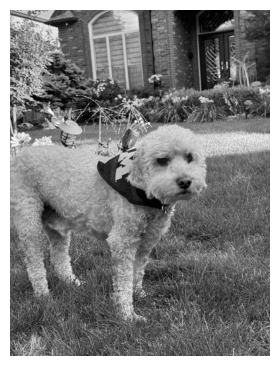

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load the image and convert to grayscale
img = Image.open('imgs/junior.jpeg').convert('L')
img_arr = np.rot90(np.array(img), k=3)

# Show the grayscale image
plt.figure(figsize=(4*1.5, 3*1.5))
plt.imshow(img_arr, cmap='gray')
plt.axis('off')
plt.show()

This image is 300 pixels wide and 400 pixels tall. Since the image is grayscale, each pixel's intensity can be represented by a number between 0 and 255, where 0 is black and 255 is white. These intensities can be stored in a $400 \times 300$ matrix. The rank of this matrix is likely $300$, since it's extremely unlikely that any of the $300$ columns of the image are exactly representable as a linear combination of other columns.

But, as the SVD reveals, the image can be approximated well by a rank-$k$ matrix, for a $k$ that is much smaller than $300$. We build this low-rank approximation of the image by summing up $k$ rank-one matrices.

$$\text{rank } k \text{ approximation of image} = \sum_{i=1}^k \sigma_i \vec u_i \vec v_i^T$$

A slider should appear below, allowing you to select a value of $k$ and see the corresponding rank-$k$ approximation of Junior.

In [9]:
import numpy as np
import plotly.graph_objs as go
from PIL import Image

IMAGE_PATH = 'imgs/junior.jpeg'

# Load image (fallback to dummy if not found), rotate 90º clockwise, and resize to 3:4 aspect ratio (e.g., 300x400)
try:
    img = Image.open(IMAGE_PATH).convert('L')
    img = img.rotate(-90, expand=True)  # Rotate 90º clockwise
    img = img.resize((300, 400), Image.LANCZOS)  # 3:4 aspect ratio (width, height)
    img_arr = np.array(img)
except FileNotFoundError:
    H, W = 400, 300  # 3:4 aspect ratio
    img_arr = np.zeros((H, W), dtype=np.uint8)
    for i in range(H):
        for j in range(W):
            img_arr[i, j] = 200 if ((i // 10) % 2 == (j // 10) % 2) else 50

# Compute SVD
U, S, VT = np.linalg.svd(img_arr.astype(float), full_matrices=False)
max_k = len(S)

def get_reconstruction(k):
    k = max(1, min(k, len(S)))
    Uk = U[:, :k]
    Sk = S[:k]
    VTk = VT[:k, :]
    recon = Uk @ np.diag(Sk) @ VTk
    return 255 - np.clip(recon, 0, 255).astype(np.uint8)

# k=1, k=31, k=61, k=91, ..., max allowed (up to len(S))
ks = list(range(1, 51))
if ks[-1] != max_k-1:
    ks.append(max_k)

# Create frames (each frame is a Heatmap of the reconstructed image)
frames = []
for k in ks:
    z = get_reconstruction(k)
    frames.append(
        go.Frame(
            data=[
                go.Heatmap(
                    z=z,
                    zmin=0,
                    zmax=255,
                    colorscale=[[0, "white"], [1, "black"]],
                    showscale=False
                )
            ],
            name=str(k)
        )
    )

# Initial trace uses k=1
initial_z = get_reconstruction(1)
initial_trace = go.Heatmap(z=initial_z, zmin=0, zmax=255, colorscale=[[0, "white"], [1, "black"]], showscale=False)

fig = go.Figure(
    data=[initial_trace],
    frames=frames
)

# Slider that calls animate on each frame
slider_steps = []
for k in ks:
    step = {
        "args": [
            [str(k)],  # frame name
            {
                "frame": {"duration": 0, "redraw": True},
                "mode": "immediate",
                "transition": {"duration": 0}
            }
        ],
        "label": str(k),
        "method": "animate"
    }
    slider_steps.append(step)

sliders = [{
    "active": 0,
    "pad": {"t": 50},
    "steps": slider_steps,
    "currentvalue": {"prefix": "Rank k: ", "font": {"size": 14}}
}]

fig.update_layout(
    sliders=sliders,
    width=300,   # width matches aspect ratio
    height=480,  # height matches aspect ratio
    margin=dict(l=20, r=20, t=0, b=0),
    font=dict(family="Avenir"),
)

# Hide axes
fig.update_xaxes(visible=False)
fig.update_yaxes(visible=False)
fig.update_yaxes(autorange="reversed")

fig.show()

To store the full image, we need to store $400 \cdot 300 = 120{,}000$ numbers. But to store a rank-$k$ approximation of the image, we only need to store $(1 + 400 + 300)k = 701k$ numbers – only the first $k$ singular values, along with $\vec u_1, \vec u_2, ..., \vec u_k$ (each of which has 400 numbers), and $\vec v_1, \vec v_2, ..., \vec v_k$ (each of which has 300 numbers). If we're satisfied with a rank-30 approximation, we only need to store $701 \cdot 30 = 21{,}030$ numbers, which is a compression of $\frac{120{,}000}{21{,}030} \approx 5.7$ times!

---

## Computing the SVD

Finally, I'll show you how to use `numpy` to compute the SVD of a matrix. The key function is `np.linalg.svd`. Let's apply it to our familiar example,

$$\underbrace{\begin{bmatrix}
3 & 2 & 5 \\
2 & 3 & 5 \\
2 & -2 & 0 \\
5 & 5 & 10
\end{bmatrix}}_X = \underbrace{\begin{bmatrix} \frac{1}{\sqrt{6}} & \frac{1}{3\sqrt{2}} & -\frac{1}{\sqrt{3}} & -\frac{2}{3} \\ \frac{1}{\sqrt{6}} & -\frac{1}{3\sqrt{2}} & -\frac{1}{\sqrt{3}} & \frac{2}{3} \\ 0 & \frac{2\sqrt{2}}{3} & 0 & \frac{1}{3} \\ \frac{2}{\sqrt{6}} & 0 & \frac{1}{\sqrt{3}} & 0 \end{bmatrix}}_{U} \underbrace{\begin{bmatrix} 15 & 0 & 0 \\ 0 & 3 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & 0 \end{bmatrix}}_{\Sigma} \underbrace{\begin{bmatrix} \frac{1}{\sqrt{6}} & \frac{1}{\sqrt{6}} & \frac{2}{\sqrt{6}} \\ \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}} & 0 \\ \frac{1}{\sqrt{3}} & \frac{1}{\sqrt{3}} & -\frac{1}{\sqrt{3}} \end{bmatrix}}_{V^T}$$


In [10]:
X = np.array([[3, 2, 5],
              [2, 3, 5],
              [2, -2, 0],
              [5, 5, 10]])
              
u, s, vt = np.linalg.svd(X)
u.shape, s.shape, vt.shape

((4, 4), (3,), (3, 3))

By default, it computes the full SVD, which is why `u` is of shape $4 \times 4$ and `vt` is of shape $3 \times 3$, even though $\text{rank}(X) = 2$.

`s` is returned as a 1-dimensional array of singular values.

In [11]:
s

array([15.,  3.,  0.])

If we'd like to use `u`, `s`, and `vt` to reconstruct $X$, we need to reshape `s` into a matrix with the same shape as $X$.

In [12]:
ss = np.zeros(X.shape)
ss[np.arange(len(s)), np.arange(len(s))] = s
ss

array([[15.,  0.,  0.],
       [ 0.,  3.,  0.],
       [ 0.,  0.,  0.],
       [ 0.,  0.,  0.]])

In [13]:
u @ ss @ vt

array([[ 3.,  2.,  5.],
       [ 2.,  3.,  5.],
       [ 2., -2.,  0.],
       [ 5.,  5., 10.]])

**Notice**: The signs of the columns of $U$ and $V$ are not uniquely determined by the SVD. For example, we could replace $\vec u_1$ with $-\vec u_1$ and $\vec v_1$ with $-\vec v_1$ to get the same matrix $X$. The values for $U$ we found had flipped signs for columns 1, 2 relative to the values returned by `np.linalg.svd`.

$$\text{our } U = \begin{bmatrix} \frac{1}{\sqrt{6}} & \frac{1}{3\sqrt{2}} & -\frac{1}{\sqrt{3}} & -\frac{2}{3} \\ \frac{1}{\sqrt{6}} & -\frac{1}{3\sqrt{2}} & -\frac{1}{\sqrt{3}} & \frac{2}{3} \\ 0 & \frac{2\sqrt{2}}{3} & 0 & \frac{1}{3} \\ \frac{2}{\sqrt{6}} & 0 & \frac{1}{\sqrt{3}} & 0 \end{bmatrix}$$

In [14]:
np.set_printoptions(precision=8, suppress=True)

In [15]:
u

array([[-0.40824829,  0.23570226, -0.45735398, -0.75405909],
       [-0.40824829, -0.23570226, -0.68098866,  0.56038577],
       [-0.        ,  0.94280904, -0.05590867,  0.32861122],
       [-0.81649658, -0.        ,  0.56917132,  0.09683666]])

- The first column of `numpy`'s `u` is the negative of our first column of $U$.
- Both second columns are the same.
- The latter two columns are different. Why? There are infinitely many orthogonal bases for the null space of $X^T$, which are what the last two columns of $U$ represent. We just picked a different choice than `numpy` did.

---

## Key Takeaways

To recap:

1. All $n \times d$ matrices $X$ have a singular value decomposition $X = U \Sigma V^T$, where $U$ is $n \times n$, $\mathcal{\Sigma}$ is $n \times d$, and $V$ is $d \times d$.

:::{figure} imgs/full-svd.png
:width: 1000px
:align: center
:::

2. The columns of $U$ are orthonormal eigenvectors of $XX^T$; these are called the **left singular vectors** of $X$.
3. The columns of $V$ are orthonormal eigenvectors of $X^TX$; these are called the **right singular vectors** of $X$.
4. Both $XX^T$ and $X^TX$ share the same non-zero eigenvalues; the singular values of $X$ are the square roots of these eigenvalues. 
    The number of non-zero singular values is equal to the rank of $X$. It's important that we sort the singular values in decreasing order, so that $\sigma_1 \geq \sigma_2 \geq ... \geq \sigma_r > 0$, and place the singular vectors in the columns of $U$ and $V$ in the same order.
$$\sigma_i = \sqrt{\lambda_i}$$

5. A typical recipe for computing the SVD is to:
    1. Compute $X^TX$. Place its eigenvectors in the columns of $V$, and place the square roots of its eigenvalues in the diagonal of $\mathcal{\Sigma}$.
    2. To find each $\vec u_i$, use $X \vec v_i = \sigma_i \vec u_i$, i.e. $\vec u_i = \frac{1}{\sigma_i} X \vec v_i$.
    3. The above rule only works for $\sigma_i > 0$. If $\sigma_i = 0$, then the remaining $\vec u_i$'s must be eigenvectors of $XX^T$ for the eigenvalue 0, meaning they must lie in the nullspace of $X^T$.

6. The SVD allows us to interpret the linear transformation of multiplying by $X$ as a composition of a rotation by $V^T$, a scaling/stretching by $\mathcal{\Sigma}$, and a rotation by $U$.
7. The SVD $X = U \Sigma V^T$ can be viewed as a sum of rank-one matrices:
    $$X = \sum_{i=1}^r \sigma_i \vec u_i \vec v_i^T$$
    Each piece $\sigma_i \vec u_i \vec v_i^T$ is a rank-one matrix, consisting of the outer product of $\vec u_i$ and $\vec v_i$. This summation view can be used to compute a low-rank approximation of $X$ by summing fewer than $r$ of these rank-one matrices.
    $$X_k = \sum_{i=1}^k \sigma_i \vec u_i \vec v_i^T$$